# Model Development and Evaluation

This notebook trains and evaluates several machine learning models to classify breast tumors as benign or malignant using the Wisconsin Diagnostic Breast Cancer dataset.

**Models Evaluated**:
- Logistic Regression (No regularization)
- Logistic Regression (L1 regularization)
- Logistic Regression (L2 regularization)
- Random Forest
- Support Vector Machine

**Evaluation Metrics**: accuracy, sensitivity, specificity, AUC-ROC, and confusion matrices.

### Imports

In [ ]:
import sys
from pathlib import Path

# Get repo root (one level above notebooks/)
repo_root = Path().resolve().parent
src_path = repo_root / "src"

# Add src folder to Python path
if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

# import modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, precision_recall_curve
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# import custom modules (located in src/)
from preprocessing import load_raw_data, get_Xy, split_data
from pipelines import logistic_pipeline, rf_pipeline, svm_pipeline
from train import train_model
from tune import get_param_grid, tune_model, extract_feature_importance
from evaluate import evaluate_model, cross_validate_model
from compare import compare_models

# Suppress sklearn warnings (clean output)
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="sklearn")
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")


### Data Preparation

In [18]:
data_path = "../data/raw/wdbc.data"

df = load_raw_data(data_path)

X, y = get_Xy(df) 

X_train, X_test, y_train, y_test = split_data(X, y)

print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])


Training samples: 455
Test samples: 114


### PCA Visualization of Tumor Types
Principle Components Analysis (PCA) reduces the high-dimensional feature space to two dimensions to visualize how benign and malignant tumors separate. In the plot below, the malignant tumors cluster separately from the benign tumors, suggesting models will be able to classify them well. The first two principle components explain roughly 63% of the variance.

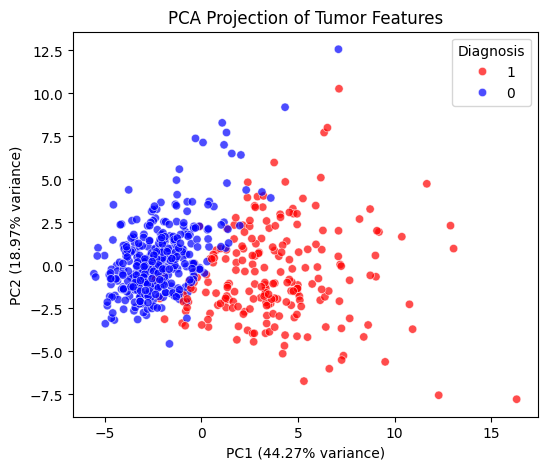

In [ ]:
# scale the full feature set for visualization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# get variance explained
pc1_var = pca.explained_variance_ratio_[0]
pc2_var = pca.explained_variance_ratio_[1]

# create DataFrame
pca_df = pd.DataFrame(X_pca, columns = ["PC1", "PC2"])
pca_df["Diagnosis"] = y.values

# plot
plt.figure(figsize=(6,5))

sns.scatterplot(
    data = pca_df,
    x = "PC1",
    y = "PC2",
    hue = "Diagnosis",
    palette = {1: "red", 0: "blue"},
    alpha = 0.7
)

plt.title("PCA Projection of Tumor Features")
plt.xlabel(f"PC1 ({pc1_var:.2%} variance)")
plt.ylabel(f"PC2 ({pc2_var:.2%} variance)")

plt.legend(title = "Diagnosis")

plt.show()

### Baseline Model: Logistic Regression (No Regularization)

In [ ]:
# set up pipeline
logistic_pipe = logistic_pipeline(penalty=None, C=1.0)

# train model
trained_logistic = train_model(logistic_pipe, X_train, y_train)

# evaluate model 
metrics, cm = evaluate_model(
    trained_logistic, 
    X_test, y_test, 
    model_name="Logistic (Baseline)")

metrics

,Accuracy,Sensitivity,Specificity,ROC-AUC,Precision,F1-Score
Model,,,,,,
Logistic (Baseline),0.9386,0.881,0.9722,0.9669,0.9487,0.9136


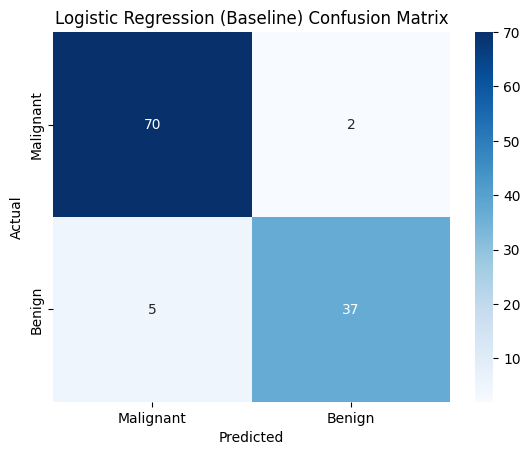

In [ ]:
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Malignant", "Benign"],
    yticklabels=["Malignant", "Benign"]
)

plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.title("Logistic Regression (Baseline) Confusion Matrix")

plt.show()

### Compare Multiple Models
Although logistic regression in sklearn uses an L2 penalty as the default, we will explore how our results change with and without regularization. 

We test 3 different baseline classifier models: logistic regression, random forest, and support vector.

In [ ]:
# compare 3 baseline models (sklearn default settings)
models = {
    "Logistic (L2)": logistic_pipeline(),
    "Random Forest": rf_pipeline(),
    "Support Vector": svm_pipeline()
}

lr_models = {
    "Logistic (No Reg)": logistic_pipeline(penalty=None),
    "Logistic (L1 Reg)": logistic_pipeline(penalty="l1"),
    "Logistic (L2 Reg)": logistic_pipeline(penalty="l2")
}

results, cms, trained_models = compare_models(
    models, 
    X_train, 
    y_train, 
    X_test, 
    y_test
)

results = results.sort_values(by="ROC-AUC",ascending=False).style.highlight_max(color="seagreen")
results

,Accuracy,Sensitivity,Specificity,ROC-AUC,Precision,F1-Score
Model,,,,,,
Logistic (L2),0.964900,0.928600,0.986100,0.996000,0.975000,0.951200
Support Vector,0.973700,0.928600,1.000000,0.994700,1.000000,0.963000
Random Forest,0.964900,0.904800,1.000000,0.994200,1.000000,0.950000


### Visualize Confusion Matrices

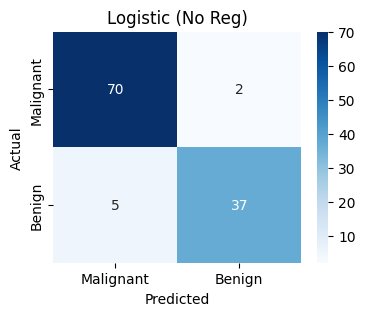

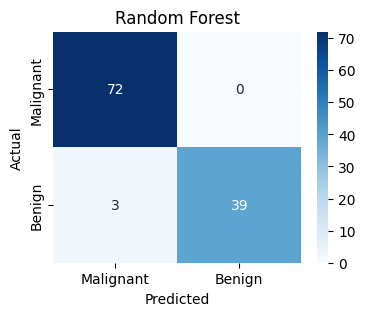

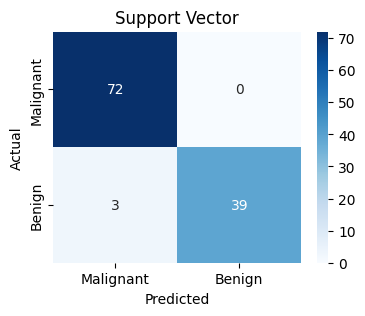

In [38]:
for name, cm in cms.items():

    plt.figure(figsize=(4,3))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Malignant", "Benign"],
        yticklabels=["Malignant", "Benign"]
    )

    plt.title(f"{name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

### ROC Curve Comparison

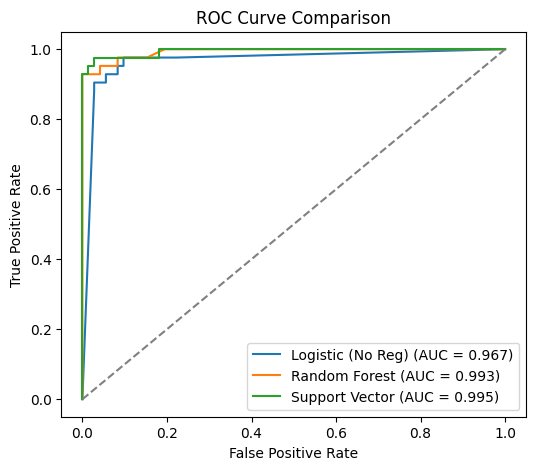

In [39]:
plt.figure(figsize=(6,5))

for name, model in trained_models.items():

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:,1]

        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_auc = auc(fpr, tpr)

        plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0,1],[0,1], linestyle="--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

### Precision-Recall Curves

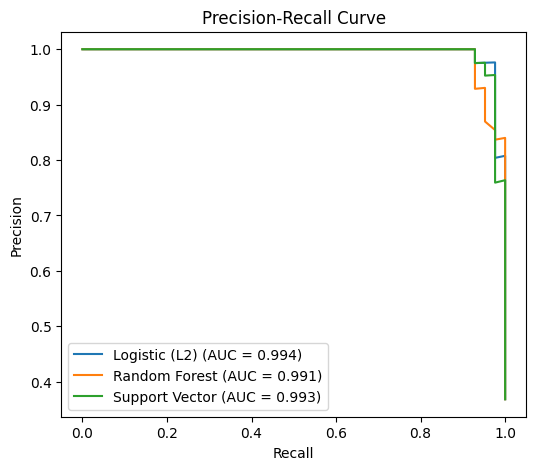

In [47]:
plt.figure(figsize=(6,5))

for name, model in trained_models.items():

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:,1]

        precision, recall, _ = precision_recall_curve(y_test, y_proba)

        pr_auc = auc(recall, precision)

        plt.plot(recall, precision, label=f"{name} (AUC = {pr_auc:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Curve")
plt.legend()

plt.show()

### Feature Importance (Random Forest)

/var/folders/mq/rnygjqw54g58vnr3thv5xq6r0000gn/T/ipykernel_846/849763480.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


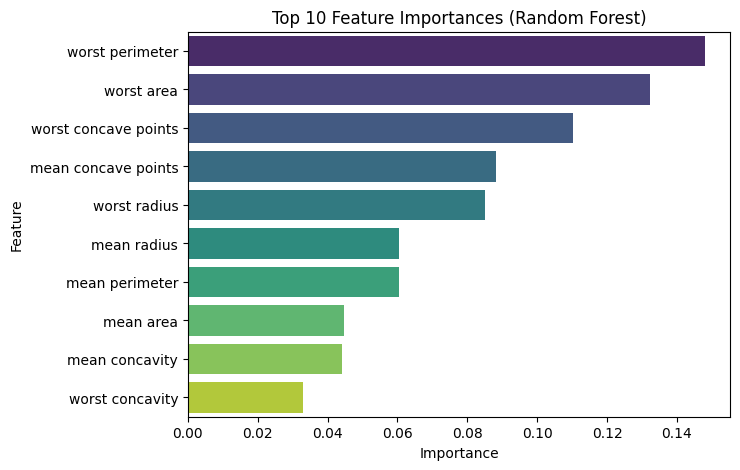

In [48]:
rf_model = trained_models["Random Forest"]
importances = rf_model.named_steps["model"].feature_importances_
features = X_train.columns

importance_df = (
    pd.DataFrame({
        "feature": features,
        "importance": importances
    })
    .sort_values("importance", ascending=False)
    .head(10)
)

plt.figure(figsize=(7,5))

sns.barplot(
    data = importance_df,
    x = "importance",
    y = "feature",
    palette = "viridis"
)

plt.title("Top 10 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

### Logistic Regression Coefficients

/var/folders/mq/rnygjqw54g58vnr3thv5xq6r0000gn/T/ipykernel_846/724059967.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


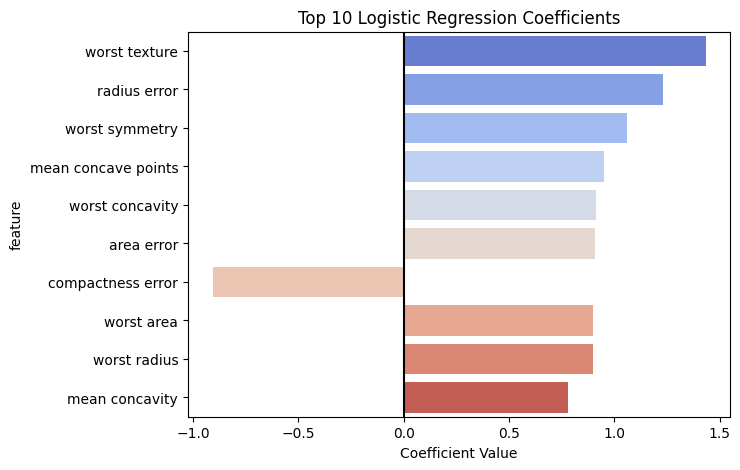

In [49]:
log_model = trained_models["Logistic (L2)"]
coefs = log_model.named_steps["model"].coef_[0]

coef_df = (
    pd.DataFrame({
        "feature": X_train.columns,
        "coefficient": coefs
    })
    .sort_values("coefficient", key=abs, ascending=False)
    .head(10)
)

plt.figure(figsize=(7,5))

sns.barplot(
    data = coef_df, 
    x="coefficient", 
    y="feature",
    palette="coolwarm"
)

plt.axvline(0, color="black")

plt.title("Top 10 Logistic Regression Coefficients")
plt.xlabel("Coefficient Value")

plt.show()

### Threshold Comparisons

In [ ]:
thresholds = [0.5, 0.4, 0.3, 0.2]

### Cross Validation

In [43]:
scoring = "roc_auc"
for name, model in trained_models.items():
    cv_metrics = cross_validate_model(model, X_train, y_train, cv=5, scoring=scoring)
    print(f"{name}\tCV {scoring}: {cv_metrics['cv_mean']:.3f} ± {cv_metrics['cv_std']:.3f}")

Logistic (No Reg)	CV roc_auc: 0.995 ± 0.005
Random Forest	CV roc_auc: 0.989 ± 0.013
Support Vector	CV roc_auc: 0.994 ± 0.005


### Discussion

<!-- Logistic regression achieved strong performance, with high sensitivity and specificity.

L1 regularization slightly reduced performance but provided a more sparse and interpretable model.

Random Forest achieved the highest ROC-AUC but at the cost of interpretability. -->

---
---
---

### For the README
The `src/` folder contains python (`.py`) scripts needed for running the `.ipynb` files contained in the `notebooks/` folder. The functions in each script help with a certain aspect of the project. At the top of each `.ipynb` in the `notebooks/` folder you will find a code block that sets up access to the `src/` folder and its functions. If you remove this code block you will not be able to properly run the notebook. 

---

Author: SE Creighton \
_Last Updated: 2026-03-05_